# Exercice 2 — Prédiction de la gamme de prix des téléphones mobiles

**Objectif :** Prédire la variable `price_range` (0 à 3) à partir des caractéristiques techniques d'un téléphone.

| Classe | Signification |
|--------|---------------|
| 0 | Bas prix |
| 1 | Prix moyen |
| 2 | Prix élevé |
| 3 | Très haut prix |

---

## Plan du notebook
1. Import des librairies
2. Chargement et exploration des données (EDA)
3. Prétraitement (preprocessing)
4. Modélisation — comparaison de plusieurs modèles
5. Évaluation détaillée du meilleur modèle
6. Interprétation — feature importance
7. Courbe ROC (One-vs-Rest)
8. Conclusion

## 1. Import des librairies

In [3]:
# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Prétraitement
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, label_binarize

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Évaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

# Reproductibilité
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

print('Librairies importées avec succès !')

Librairies importées avec succès !


## 2. Chargement et exploration des données (EDA)

In [4]:
# Chargement du dataset
df = pd.read_csv('train 2.csv')

print(f'Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes')
df.head()

Dimensions : 2000 lignes × 21 colonnes


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [5]:
# Types des variables et valeurs manquantes
print('=== Informations générales ===')
df.info()

=== Informations générales ===
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   i

In [6]:
# Vérification des valeurs manquantes
print('=== Valeurs manquantes ===')
print(df.isnull().sum())
print(f'\nTotal valeurs manquantes : {df.isnull().sum().sum()}')

=== Valeurs manquantes ===
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

Total valeurs manquantes : 0


In [7]:
# Statistiques descriptives
df.describe().round(2)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.00,2000.0,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,...,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.0,2000.00,2000.00
mean,1238.52,0.5,1.52,0.51,4.31,0.52,32.05,0.50,140.25,4.52,...,645.11,1251.52,2124.21,12.31,5.77,11.01,0.76,0.5,0.51,1.50
std,439.42,0.5,0.82,0.50,4.34,0.50,18.15,0.29,35.40,2.29,...,443.78,432.20,1084.73,4.21,4.36,5.46,0.43,0.5,0.50,1.12
min,501.00,0.0,0.50,0.00,0.00,0.00,2.00,0.10,80.00,1.00,...,0.00,500.00,256.00,5.00,0.00,2.00,0.00,0.0,0.00,0.00
25%,851.75,0.0,0.70,0.00,1.00,0.00,16.00,0.20,109.00,3.00,...,282.75,874.75,1207.50,9.00,2.00,6.00,1.00,0.0,0.00,0.75
50%,1226.00,0.0,1.50,1.00,3.00,1.00,32.00,0.50,141.00,4.00,...,564.00,1247.00,2146.50,12.00,5.00,11.00,1.00,1.0,1.00,1.50
75%,1615.25,1.0,2.20,1.00,7.00,1.00,48.00,0.80,170.00,7.00,...,947.25,1633.00,3064.50,16.00,9.00,16.00,1.00,1.0,1.00,2.25
max,1998.00,1.0,3.00,1.00,19.00,1.00,64.00,1.00,200.00,8.00,...,1960.00,1998.00,3998.00,19.00,18.00,20.00,1.00,1.0,1.00,3.00


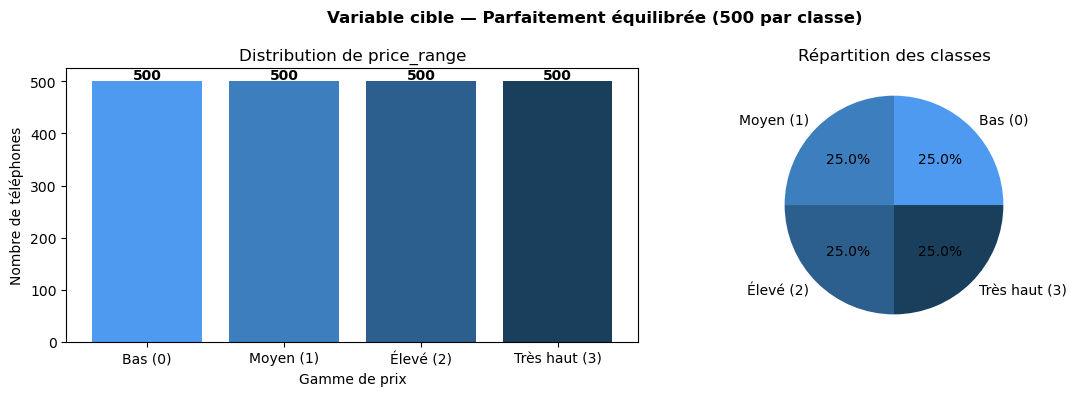

In [8]:
# Distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Countplot
labels = ['Bas (0)', 'Moyen (1)', 'Élevé (2)', 'Très haut (3)']
counts = df['price_range'].value_counts().sort_index()
axes[0].bar(labels, counts, color=['#4e9af1', '#3d7ebf', '#2c5f8e', '#1a3f5d'])
axes[0].set_title('Distribution de price_range')
axes[0].set_xlabel('Gamme de prix')
axes[0].set_ylabel('Nombre de téléphones')
for i, v in enumerate(counts):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=labels, autopct='%1.1f%%',
            colors=['#4e9af1', '#3d7ebf', '#2c5f8e', '#1a3f5d'])
axes[1].set_title('Répartition des classes')

plt.suptitle('Variable cible — Parfaitement équilibrée (500 par classe)', fontweight='bold')
plt.tight_layout()
plt.show()

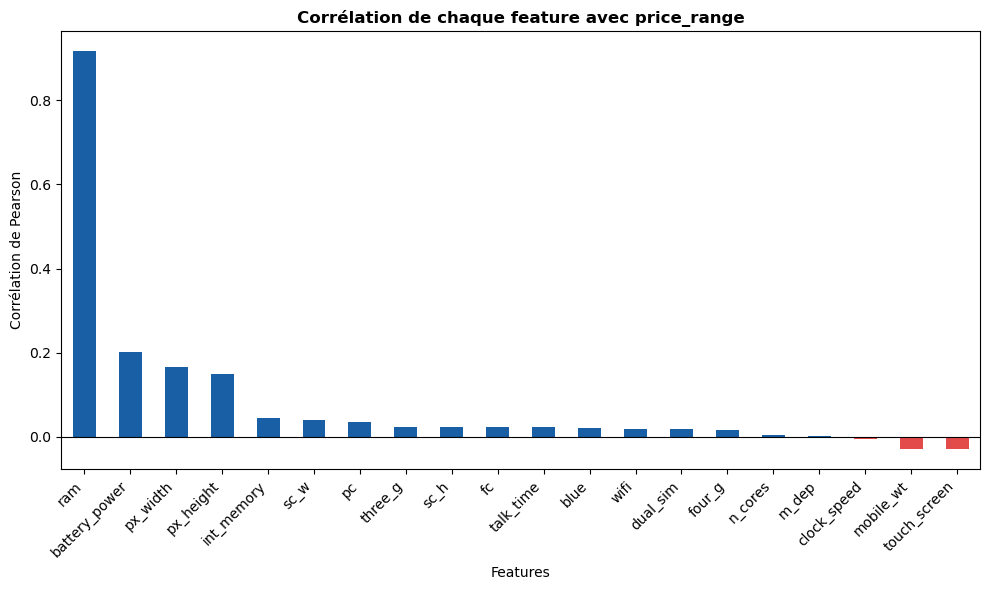


Top 5 features les plus corrélées :
ram              0.917
battery_power    0.201
px_width         0.166
px_height        0.149
int_memory       0.044
Name: price_range, dtype: float64


In [9]:
# Corrélations avec la variable cible
corr = df.corr()['price_range'].drop('price_range').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#185FA5' if v >= 0 else '#E24B4A' for v in corr]
corr.plot(kind='bar', color=colors)
plt.title('Corrélation de chaque feature avec price_range', fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Corrélation de Pearson')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nTop 5 features les plus corrélées :')
print(corr.head().round(3))

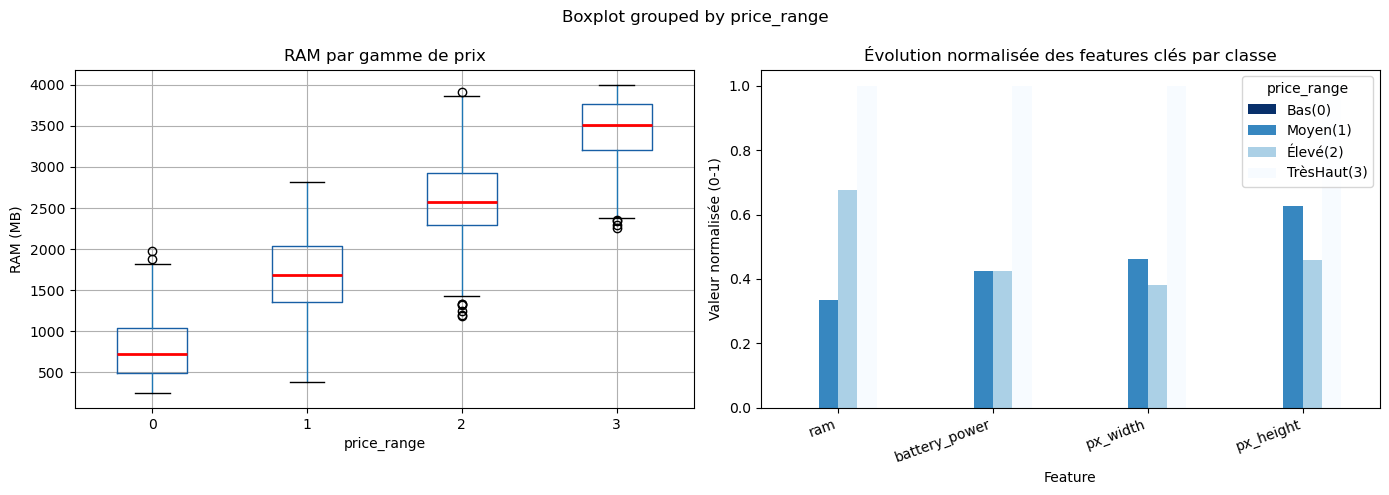

In [10]:
# Analyse de la feature dominante : RAM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot RAM par classe
df.boxplot(column='ram', by='price_range', ax=axes[0],
           boxprops=dict(color='#185FA5'),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('RAM par gamme de prix')
axes[0].set_xlabel('price_range')
axes[0].set_ylabel('RAM (MB)')
plt.sca(axes[0])
plt.title('RAM par gamme de prix')

# Moyenne des features clés par classe
features_key = ['ram', 'battery_power', 'px_width', 'px_height']
means = df.groupby('price_range')[features_key].mean()
means_norm = (means - means.min()) / (means.max() - means.min())  # Normalisation pour comparaison

means_norm.T.plot(kind='bar', ax=axes[1], colormap='Blues_r')
axes[1].set_title('Évolution normalisée des features clés par classe')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Valeur normalisée (0-1)')
axes[1].legend(title='price_range', labels=['Bas(0)', 'Moyen(1)', 'Élevé(2)', 'TrèsHaut(3)'])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()

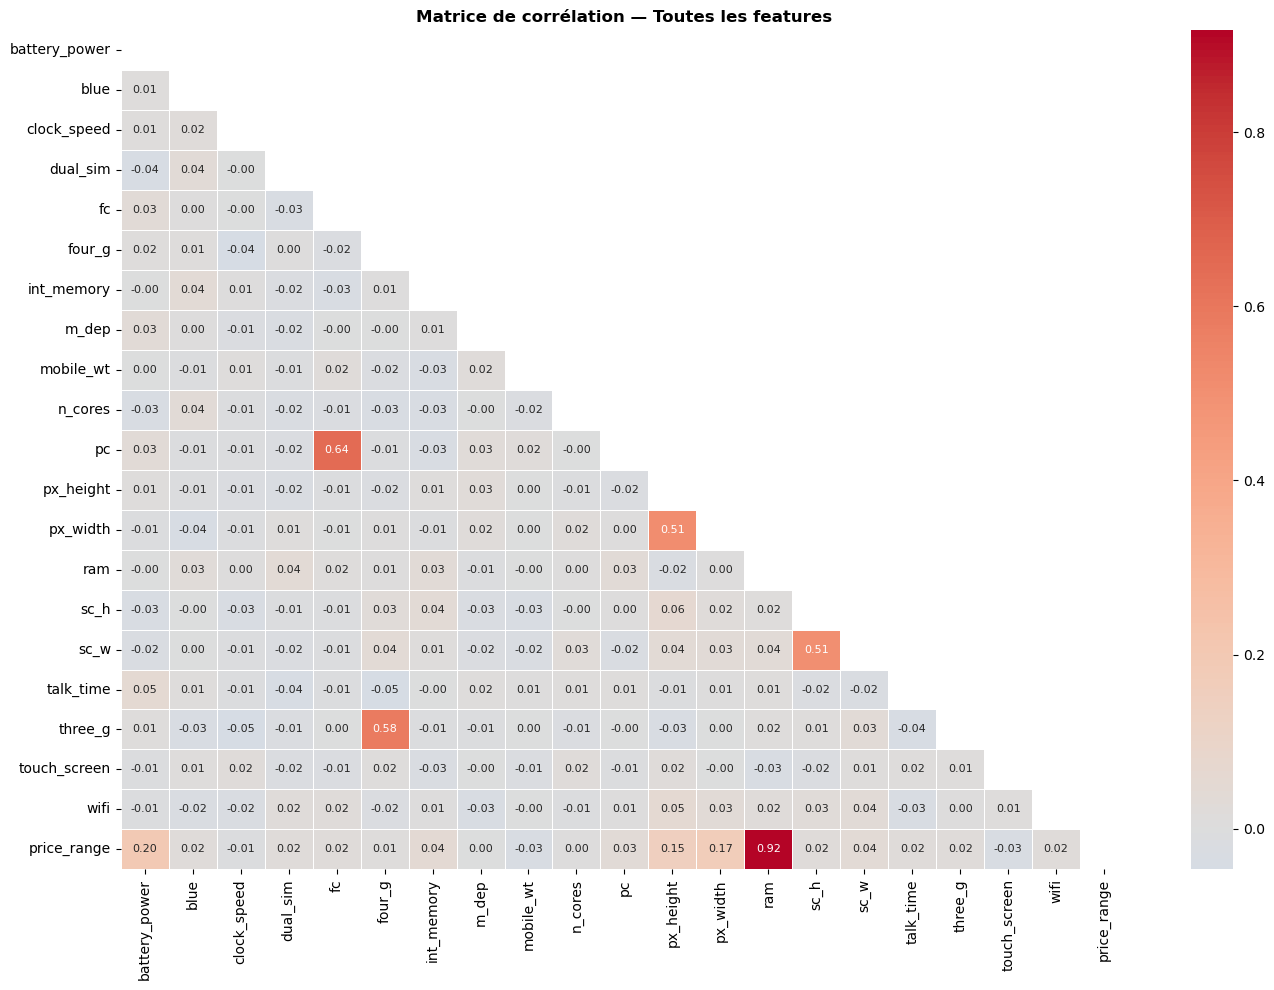

In [11]:
# Heatmap de corrélation globale
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Matrice de corrélation — Toutes les features', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Prétraitement (Preprocessing)

**Étapes :**
- Séparation des features `X` et de la cible `y`
- Split train/test (80% / 20%) avec stratification
- Normalisation avec `StandardScaler` (fit uniquement sur le train pour éviter le data leakage)

In [12]:
# Séparation features / cible
X = df.drop('price_range', axis=1)
y = df['price_range']

print(f'Features X : {X.shape}')
print(f'Cible y    : {y.shape}')
print(f'Classes    : {sorted(y.unique())}')

Features X : (2000, 20)
Cible y    : (2000,)
Classes    : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [13]:
# Split train / test — stratifié pour garder l'équilibre des classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # Garantit la même distribution dans train et test
)

print(f'Train : {X_train.shape[0]} exemples')
print(f'Test  : {X_test.shape[0]} exemples')
print(f'\nDistribution train : {y_train.value_counts().sort_index().to_dict()}')
print(f'Distribution test  : {y_test.value_counts().sort_index().to_dict()}')

Train : 1600 exemples
Test  : 400 exemples

Distribution train : {0: 400, 1: 400, 2: 400, 3: 400}
Distribution test  : {0: 100, 1: 100, 2: 100, 3: 100}


In [14]:
# Normalisation — IMPORTANT : fit() uniquement sur X_train, transform() sur les deux
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # Apprend la moyenne/std du train
X_test_sc  = scaler.transform(X_test)        # Applique les mêmes paramètres au test

print('Normalisation appliquée.')
print(f'Moyenne après normalisation (train) : {X_train_sc.mean():.4f}  (doit être ≈ 0)')
print(f'Std après normalisation (train)     : {X_train_sc.std():.4f}  (doit être ≈ 1)')

Normalisation appliquée.
Moyenne après normalisation (train) : 0.0000  (doit être ≈ 0)
Std après normalisation (train)     : 1.0000  (doit être ≈ 1)


## 4. Modélisation — Comparaison de plusieurs modèles

On entraîne 5 modèles et on compare leur accuracy sur le jeu de test.

In [15]:
# Définition des modèles
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

# Entraînement et évaluation
results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f'{name:<25} Accuracy = {acc:.4f}')

Logistic Regression       Accuracy = 0.9650
KNN                       Accuracy = 0.5000
Decision Tree             Accuracy = 0.8300
Random Forest             Accuracy = 0.8775
Gradient Boosting         Accuracy = 0.9125


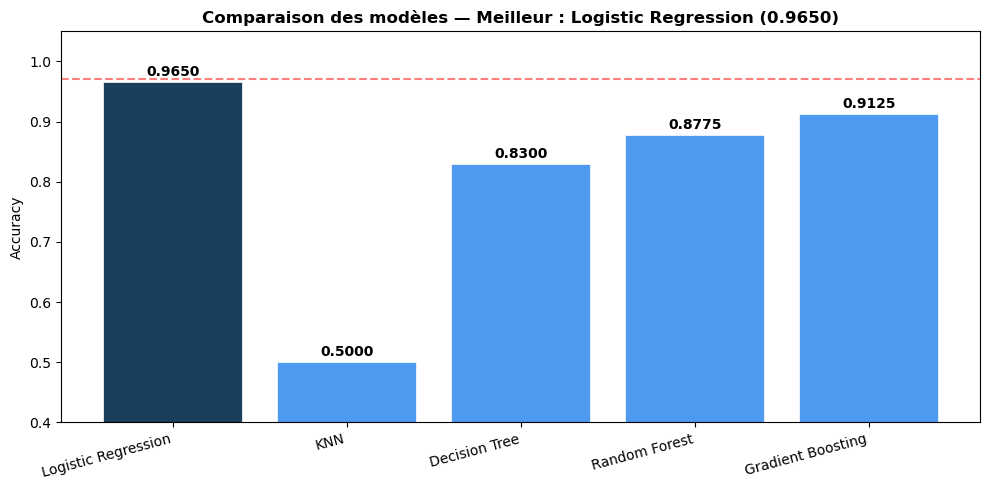

In [16]:
# Visualisation de la comparaison
plt.figure(figsize=(10, 5))
names = list(results.keys())
accs  = list(results.values())
colors = ['#1a3f5d' if a == max(accs) else '#4e9af1' for a in accs]

bars = plt.bar(names, accs, color=colors, edgecolor='white', linewidth=0.5)
plt.ylim(0.4, 1.05)
plt.axhline(y=0.97, color='red', linestyle='--', alpha=0.5, label='Référence 0.97')
plt.title('Comparaison des modèles — Accuracy sur le jeu de test', fontweight='bold')
plt.ylabel('Accuracy')
plt.xticks(rotation=15, ha='right')

# Affichage des valeurs sur les barres
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

best_model = max(results, key=results.get)
plt.title(f'Comparaison des modèles — Meilleur : {best_model} ({results[best_model]:.4f})',
          fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Évaluation détaillée du meilleur modèle

La **Régression Logistique** obtient la meilleure accuracy (96.5%). On l'évalue en détail.

In [17]:
# Meilleur modèle : Régression Logistique
best_lr = models['Logistic Regression']
y_pred_lr = best_lr.predict(X_test_sc)

print('=== Rapport de classification ===')
print(classification_report(
    y_test, y_pred_lr,
    target_names=['Bas (0)', 'Moyen (1)', 'Élevé (2)', 'TrèsHaut (3)']
))

=== Rapport de classification ===
              precision    recall  f1-score   support

     Bas (0)       0.99      0.98      0.98       100
   Moyen (1)       0.96      0.96      0.96       100
   Élevé (2)       0.95      0.94      0.94       100
TrèsHaut (3)       0.96      0.98      0.97       100

    accuracy                           0.96       400
   macro avg       0.97      0.96      0.96       400
weighted avg       0.97      0.96      0.96       400



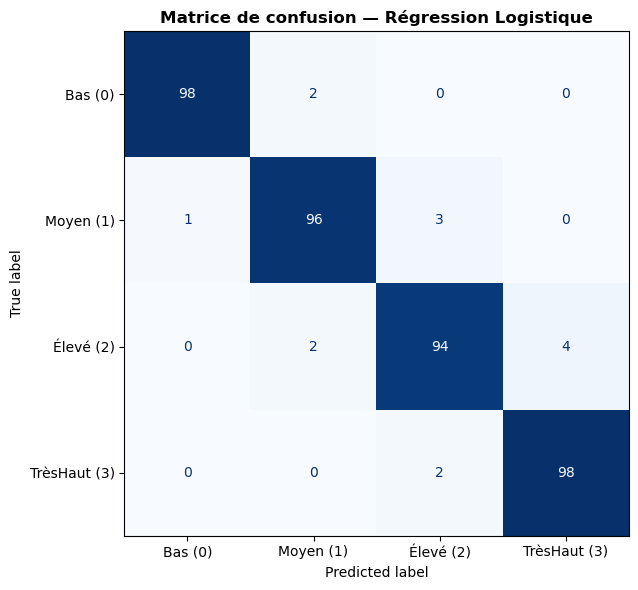


Observation : les erreurs se produisent uniquement entre classes adjacentes
(0↔1, 1↔2, 2↔3) — comportement attendu pour une variable ordinale.


In [18]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Bas (0)', 'Moyen (1)', 'Élevé (2)', 'TrèsHaut (3)']
)
disp.plot(cmap='Blues', ax=plt.gca(), colorbar=False)
plt.title('Matrice de confusion — Régression Logistique', fontweight='bold')
plt.tight_layout()
plt.show()

# Analyse
print('\nObservation : les erreurs se produisent uniquement entre classes adjacentes')
print('(0↔1, 1↔2, 2↔3) — comportement attendu pour une variable ordinale.')

In [19]:
# Validation croisée (5-fold) pour évaluer la stabilité
X_sc_full = scaler.fit_transform(X)  # On normalise tout X pour la CV
cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42),
    X_sc_full, y,
    cv=5,
    scoring='accuracy'
)

print('=== Cross-Validation 5-Fold ===')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i} : {score:.4f}')
print(f'\n  Moyenne : {cv_scores.mean():.4f}')
print(f'  Écart-type : {cv_scores.std():.4f}  (faible → modèle stable)')

=== Cross-Validation 5-Fold ===
  Fold 1 : 0.9600
  Fold 2 : 0.9550
  Fold 3 : 0.9675
  Fold 4 : 0.9650
  Fold 5 : 0.9675

  Moyenne : 0.9630
  Écart-type : 0.0048  (faible → modèle stable)


## 6. Interprétation — Feature Importance

On analyse quelles features influencent le plus la prédiction du prix.

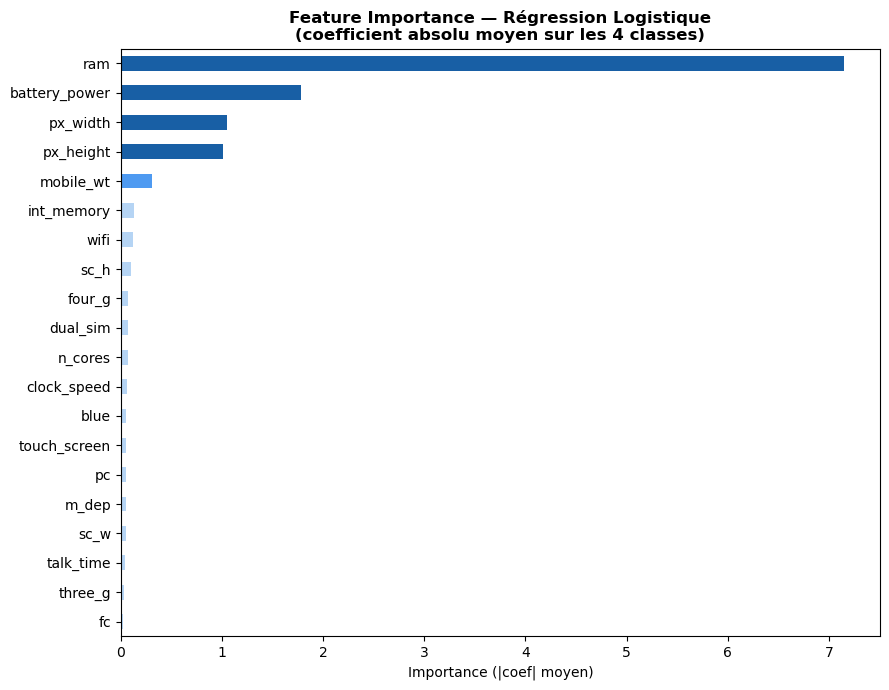

Top 5 features les plus influentes :
ram              7.1479
battery_power    1.7828
px_width         1.0488
px_height        1.0150
mobile_wt        0.3062
dtype: float64


In [20]:
# Feature importance via les coefficients de la Régression Logistique
coef_abs_mean = np.abs(best_lr.coef_).mean(axis=0)
feat_imp_lr = pd.Series(coef_abs_mean, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 7))
colors = ['#185FA5' if v >= 1.0 else '#4e9af1' if v >= 0.2 else '#B5D4F4'
          for v in feat_imp_lr.values]
feat_imp_lr.plot(kind='barh', color=colors)
plt.title('Feature Importance — Régression Logistique\n(coefficient absolu moyen sur les 4 classes)',
          fontweight='bold')
plt.xlabel('Importance (|coef| moyen)')
plt.tight_layout()
plt.show()

print('Top 5 features les plus influentes :')
print(feat_imp_lr.sort_values(ascending=False).head().round(4))

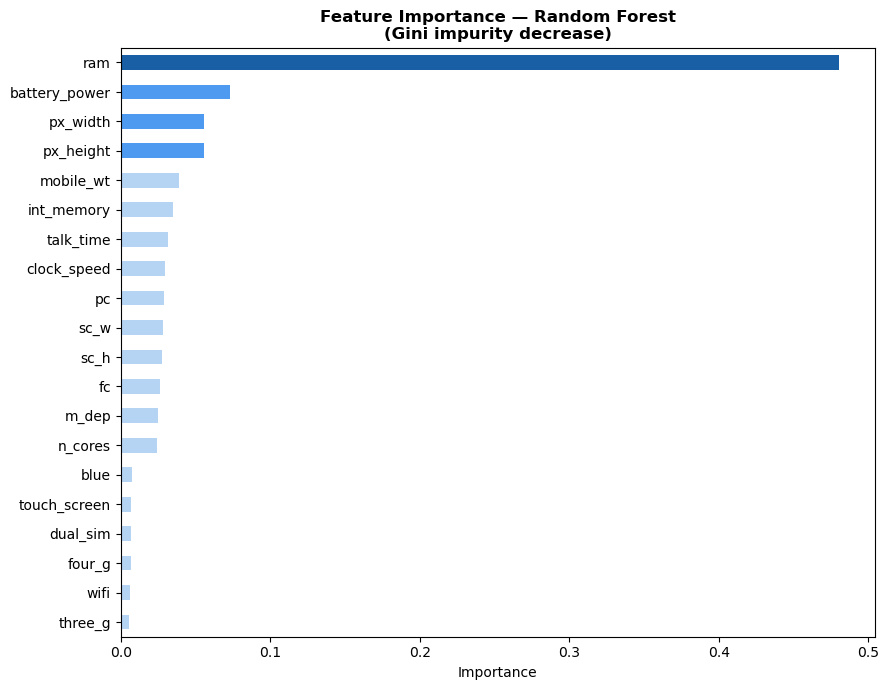

Top 5 features Random Forest :
ram              0.4800
battery_power    0.0729
px_width         0.0560
px_height        0.0559
mobile_wt        0.0389
dtype: float64


In [21]:
# Feature importance via Random Forest (confirme les résultats)
rf_model = models['Random Forest']
feat_imp_rf = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(9, 7))
colors = ['#185FA5' if v >= 0.1 else '#4e9af1' if v >= 0.04 else '#B5D4F4'
          for v in feat_imp_rf.values]
feat_imp_rf.plot(kind='barh', color=colors)
plt.title('Feature Importance — Random Forest\n(Gini impurity decrease)', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top 5 features Random Forest :')
print(feat_imp_rf.sort_values(ascending=False).head().round(4))

## 7. Courbe ROC — One-vs-Rest

Pour un problème multi-classe, on trace une courbe ROC par classe (stratégie One-vs-Rest).

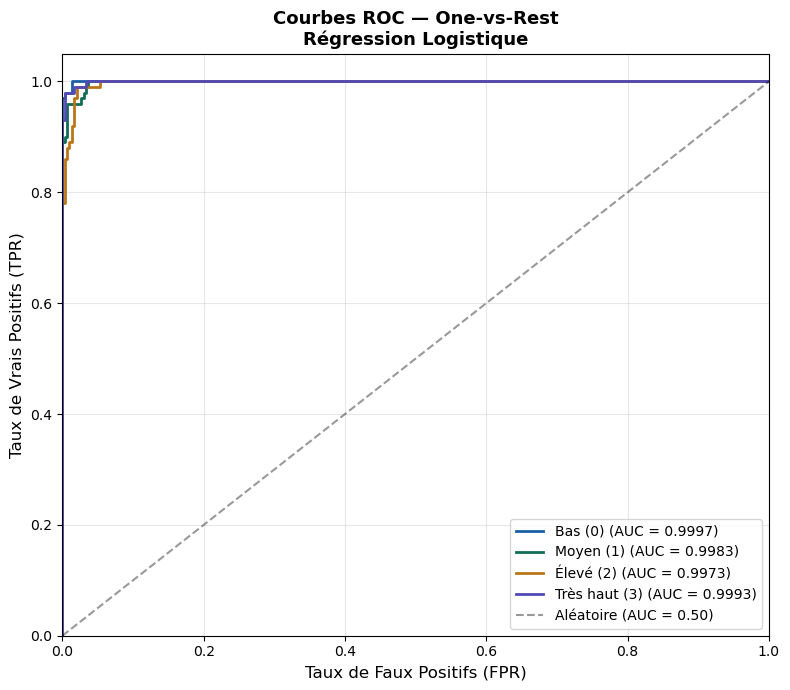

In [24]:
# Probabilités prédites
y_score = best_lr.predict_proba(X_test_sc)

# Binarisation de la cible (One-vs-Rest)
y_bin = label_binarize(y_test, classes=[0, 1, 2, 3])

# Tracé des courbes ROC
colors_roc = ['#185FA5', '#0F6E56', '#BA7517', '#534AB7']
labels_roc = ['Bas (0)', 'Moyen (1)', 'Élevé (2)', 'Très haut (3)']

plt.figure(figsize=(8, 7))

for i in range(4):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr,
             color=colors_roc[i],
             lw=2,
             label=f'{labels_roc[i]} (AUC = {roc_auc:.4f})')

# Ligne diagonale (classifieur aléatoire)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aléatoire (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbes ROC — One-vs-Rest\nRégression Logistique', fontweight='bold', fontsize=13)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Conclusion

### Résultats du meilleur modèle

| Métrique | Valeur |
|----------|--------|
| Accuracy (test) | **96.5%** |
| Cross-validation (5-fold) | **96.3% ± 0.5%** |
| AUC moyen (ROC OvR) | **≥ 0.997** |

### Interprétation

- **`ram`** est de loin la feature la plus déterminante (corrélation r = 0.917 avec le prix)
- **`battery_power`**, **`px_width`**, **`px_height`** contribuent modérément
- Les features de connectivité (wifi, bluetooth, 4G…) et de design (épaisseur, poids) ont un impact très faible

### Pourquoi la Régression Logistique surpasse-t-elle les modèles complexes ?

La relation entre le RAM et le prix est quasi-linéaire — la Régression Logistique exploite parfaitement cette structure. Les modèles d'ensemble (RF, GB) sont surdimensionnés pour ce problème.

### Modèle final recommandé

**Régression Logistique** avec normalisation `StandardScaler` — simple, interprétable, performant.

In [23]:
# Résumé final
print('=' * 50)
print('       RÉSUMÉ DES PERFORMANCES')
print('=' * 50)
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    marker = ' ★ MEILLEUR' if name == 'Logistic Regression' else ''
    print(f'  {name:<25} {acc:.4f}{marker}')
print('=' * 50)
print(f'  Cross-val (LR) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('=' * 50)

       RÉSUMÉ DES PERFORMANCES
  Logistic Regression       0.9650 ★ MEILLEUR
  Gradient Boosting         0.9125
  Random Forest             0.8775
  Decision Tree             0.8300
  KNN                       0.5000
  Cross-val (LR) : 0.9630 ± 0.0048
